<a href="https://colab.research.google.com/github/weronix123/customer-churn/blob/dev/churn_projekt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Importowanie bibliotek i wczytanie danych**

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/customer_churn_dataset-training-master.csv')
df_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/customer_churn_dataset-testing-master.csv')

In [37]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


## **Eksploracja wstępna**

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [39]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [40]:
df.shape

(440833, 12)

In [41]:
df.dtypes

,0
CustomerID,float64
Age,float64
Gender,object
Tenure,float64
Usage Frequency,float64
Support Calls,float64
Payment Delay,float64
Subscription Type,object
Contract Length,object
Total Spend,float64


## **Czyszczenie danych**

In [42]:
df.isnull().sum()

,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


In [43]:
df = df.dropna()
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [44]:
df = df.drop(columns=["CustomerID"])
df.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='object')

In [45]:
print('Duplikaty przed:', df.duplicated().sum())
df = df.drop_duplicates()
print('Duplikaty po:', df.duplicated().sum())

Duplikaty przed: 0
Duplikaty po: 0


In [46]:
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


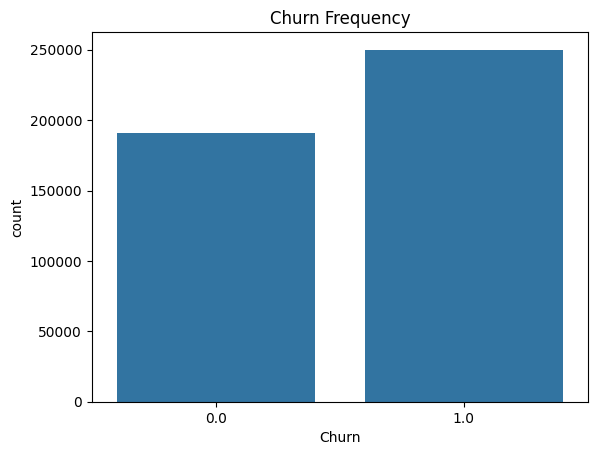

In [47]:
df['Churn'].value_counts(normalize=True)
sns.countplot(x='Churn', data=df)
plt.title('Churn Frequency')
plt.show()

## **Rozkład wartości odstających**

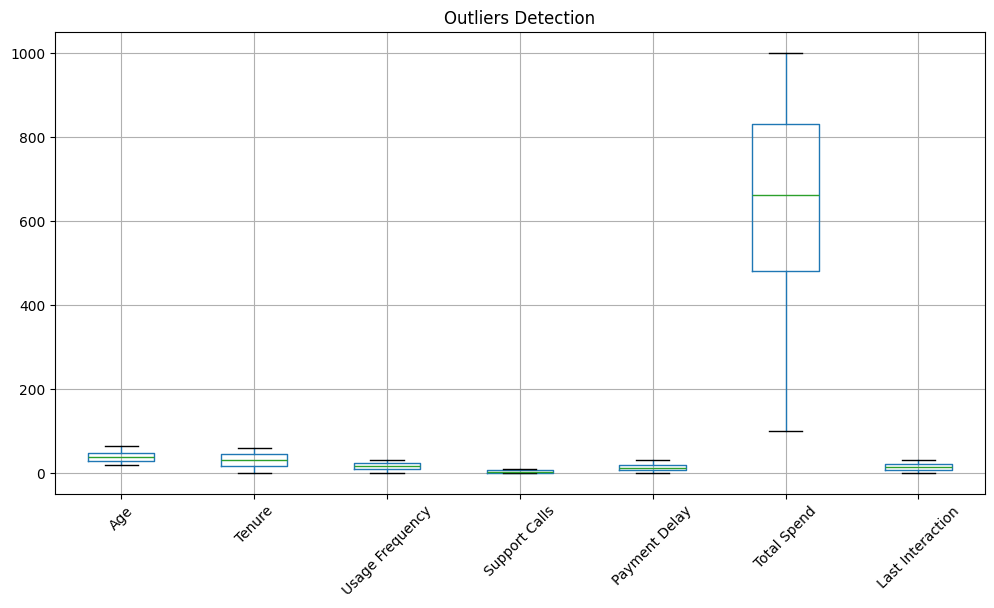

In [48]:
plt.figure(figsize=(12,6))
df[['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']].boxplot()
plt.xticks(rotation=45)
plt.title('Outliers Detection')
plt.show()

## **Rozkład wieku i wydatków - wykrywanie błędów czy nie ma danych na minusie**

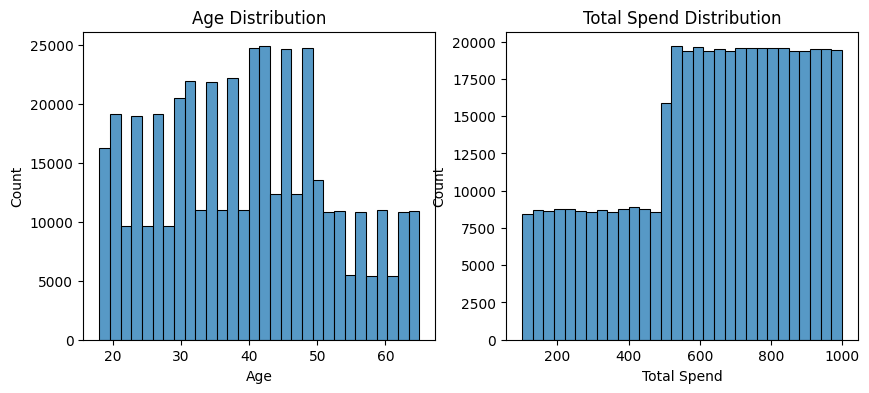

In [49]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['Age'], bins=30)
plt.title('Age Distribution')

plt.subplot(1,2,2)
sns.histplot(df['Total Spend'], bins=30)
plt.title('Total Spend Distribution')
plt.show()

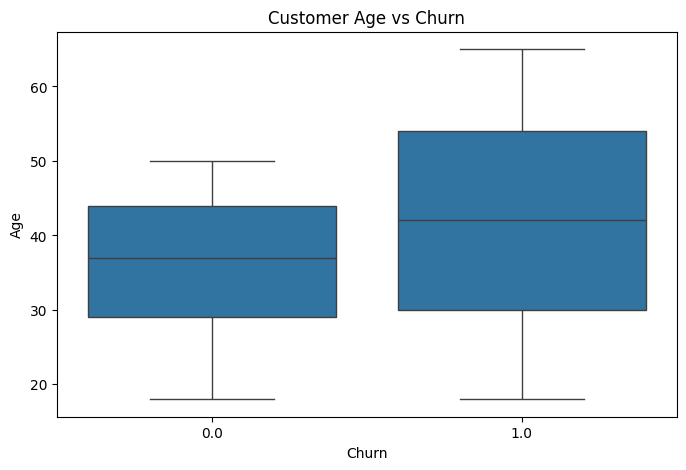

In [50]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Age', data=df)
plt.title('Customer Age vs Churn')
plt.show()

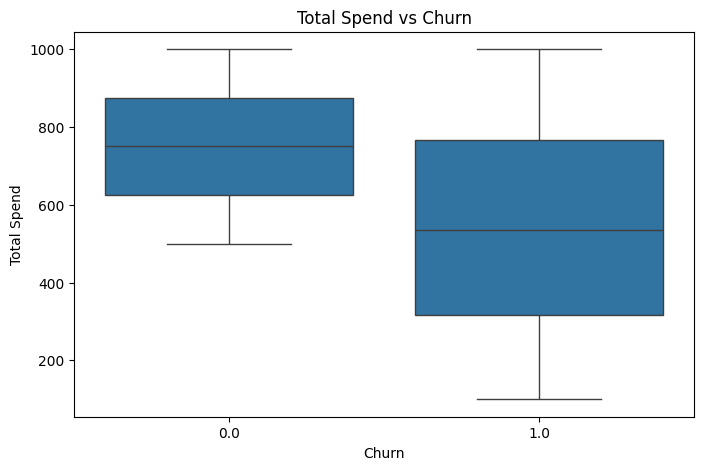

In [51]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Total Spend', data=df)
plt.title('Total Spend vs Churn')
plt.show()

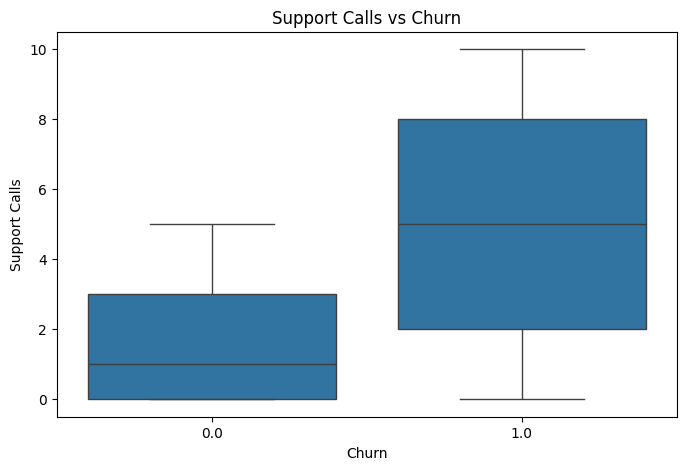

In [52]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Support Calls', data=df)
plt.title('Support Calls vs Churn')
plt.show()

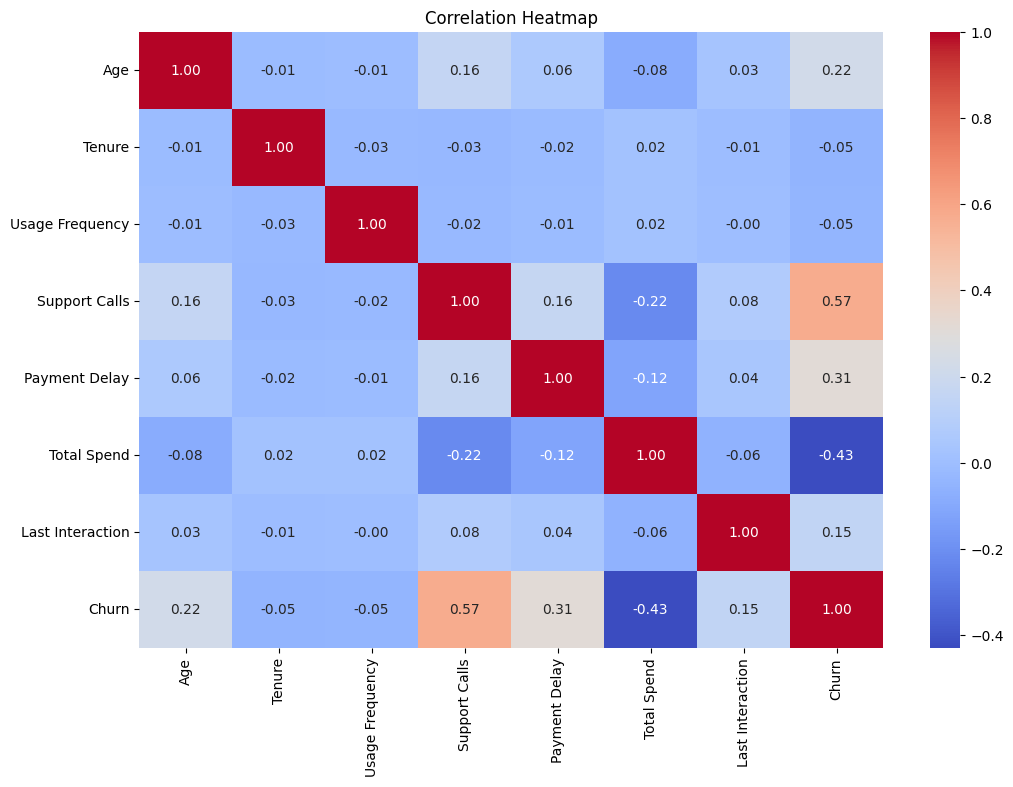

In [53]:
correlation_matrix=df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

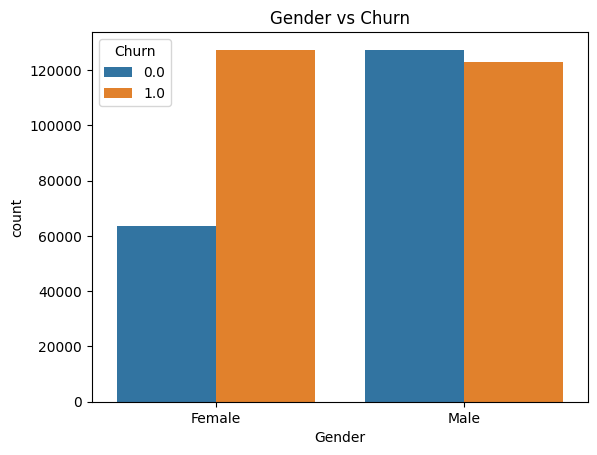

In [54]:
sns.countplot(x='Gender', hue='Churn', data=df)
plt.title('Gender vs Churn')
plt.show()

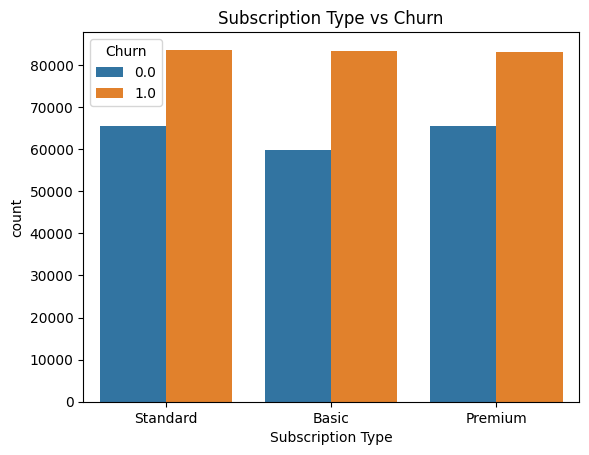

In [55]:
sns.countplot(x='Subscription Type', hue='Churn', data=df)
plt.title('Subscription Type vs Churn')
plt.show()

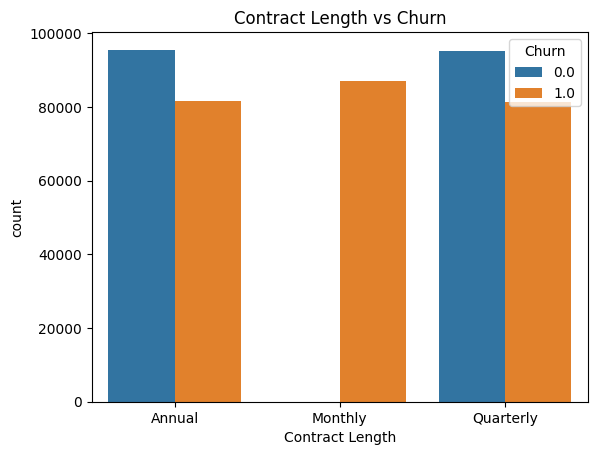

In [56]:
sns.countplot(x='Contract Length', hue='Churn', data=df)
plt.title('Contract Length vs Churn')
plt.show()

## **Kodowanie zmiennych kategorycznych**

In [57]:
df = pd.get_dummies(df, columns=['Gender', 'Subscription Type', 'Contract Length'], drop_first=True)

In [58]:
df.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,1.0,False,False,True,False,False
1,65.0,49.0,1.0,10.0,8.0,557.0,6.0,1.0,False,False,False,True,False
2,55.0,14.0,4.0,6.0,18.0,185.0,3.0,1.0,False,False,False,False,True
3,58.0,38.0,21.0,7.0,7.0,396.0,29.0,1.0,True,False,True,True,False
4,23.0,32.0,20.0,5.0,8.0,617.0,20.0,1.0,True,False,False,True,False


In [59]:
X = df.drop(columns=['Churn'])
y = df['Churn']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## **Przygotowanie zbioru testowego**

In [60]:
df_test = df_test.dropna()
df_test = df_test.drop(columns=['CustomerID'])
df_test = pd.get_dummies(df_test, columns=['Gender', 'Subscription Type', 'Contract Length'], drop_first=True)
df_test.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,22,25,14,4,27,598,9,1,False,False,False,True,False
1,41,28,28,7,13,584,20,0,False,False,True,True,False
2,47,27,10,2,29,757,21,0,True,True,False,False,False
3,35,9,12,5,17,232,18,0,True,True,False,False,True
4,53,58,24,9,2,533,18,0,False,False,True,False,False


## **Normalizacja**

In [61]:
num_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
            'Payment Delay', 'Total Spend', 'Last Interaction']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_train.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
318331,0.210377,0.855271,1.651238,-0.197156,-1.085320,1.300956,-0.753449,True,False,True,False,False
429062,-0.512784,0.681455,0.137056,-0.848223,0.246158,1.478368,-0.288211,False,False,True,False,False
60074,-1.075242,-1.056712,1.651238,0.128377,-0.116972,0.698312,-1.102379,False,True,False,False,True
12759,-0.834189,-1.288467,0.835909,2.081578,1.335549,-2.130477,0.525957,False,False,False,False,True
357321,-0.111028,-1.230528,0.486483,-1.173756,-1.569494,0.195568,0.409648,True,False,False,False,False


In [62]:
X_test = df_test.drop(columns=['Churn'])
y_test = df_test['Churn']

X_test[num_cols] = scaler.transform(X_test[num_cols])

Regresja logistyczna

In [63]:
results = {}
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_val)
results['Logistic Regression'] = accuracy_score(y_val, y_pred_log)

print("Regresja Logistyczna")
print(classification_report(y_val, y_pred_log, digits=4))

Regresja Logistyczna
              precision    recall  f1-score   support

         0.0     0.8575    0.9038    0.8801     38167
         1.0     0.9234    0.8854    0.9040     50000

    accuracy                         0.8934     88167
   macro avg     0.8905    0.8946    0.8920     88167
weighted avg     0.8949    0.8934    0.8936     88167



In [64]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)
results['Random Forest'] = accuracy_score(y_val, y_pred_rf)

print("\nRandom Forest Classifier")
print(classification_report(y_val, y_pred_rf, digits=4))


Random Forest Classifier
              precision    recall  f1-score   support

         0.0     0.9990    0.9999    0.9995     38167
         1.0     0.9999    0.9992    0.9996     50000

    accuracy                         0.9995     88167
   macro avg     0.9995    0.9996    0.9995     88167
weighted avg     0.9995    0.9995    0.9995     88167



In [65]:
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_val)
results['XGBoost'] = accuracy_score(y_val, y_pred_xgb)

print("\nXGBoost Classifier")
print(classification_report(y_val, y_pred_xgb, digits=4))


XGBoost Classifier
              precision    recall  f1-score   support

         0.0     0.9998    1.0000    0.9999     38167
         1.0     1.0000    0.9999    0.9999     50000

    accuracy                         0.9999     88167
   macro avg     0.9999    0.9999    0.9999     88167
weighted avg     0.9999    0.9999    0.9999     88167




ZESTAWIENIE DOKŁADNOŚCI MODELI
Logistic Regression: 0.8934
Random Forest: 0.9995
XGBoost: 0.9999


<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

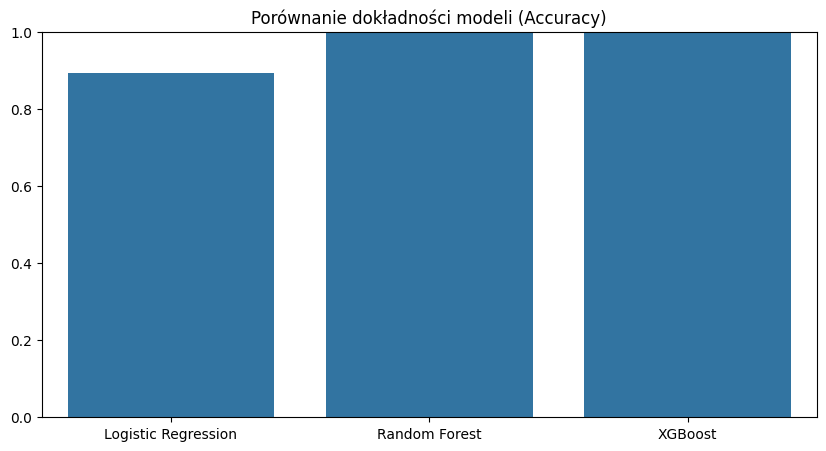

In [66]:
print("\nZESTAWIENIE DOKŁADNOŚCI MODELI")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")
    plt.figure(figsize=(10, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title('Porównanie dokładności modeli (Accuracy)')
plt.ylim(0, 1)
plt.show()

In [67]:
df.columns.tolist()

['Age',
 'Tenure',
 'Usage Frequency',
 'Support Calls',
 'Payment Delay',
 'Total Spend',
 'Last Interaction',
 'Churn',
 'Gender_Male',
 'Subscription Type_Premium',
 'Subscription Type_Standard',
 'Contract Length_Monthly',
 'Contract Length_Quarterly']